<a href="https://colab.research.google.com/github/FirmanRcode/Bank-fraud-detection-with-process-mining-and-ensemble-learning/blob/main/BNSP_BI_Analyst_APL02_UW_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Analisis Kinerja Underwriter (UW) – Track Record 7 Hari
## FR.APL.02 – Asesmen Mandiri: Business Intelligence Analyst
### Skema Sertifikasi BNSP | Kode: DSS.02.00.23

---

**Dataset:** UW Track Record (Return D1–D7 pasca listing IPO di Bursa Efek Indonesia)

**Tujuan Analisis:**  
Menganalisis kinerja underwriter saham IPO berdasarkan return 7 hari pertama setelah listing, mencakup seluruh unit kompetensi APL 02:

| Unit | Judul |
|------|-------|
| Unit 1 – J.62DMI00.004.1 | Mengumpulkan Data |
| Unit 2 – J.62DMI00.005.1 | Menelaah Data |
| Unit 3 – J.62DMI00.006.1 | Memvalidasi Data |
| Unit 4 – J.62DMI00.007.1 | Menentukan Objek Data |
| Unit 5 – J.62DMI00.009.1 | Mengkonstruksi Data |
| Unit 6 – J.62DMI00.011.1 | Mengintegrasikan Data |
| Unit 7 – J.62DMS00.015.1 | Membuat Business Intelligence |

---
##  UNIT KOMPETENSI 1: Mengumpulkan Data
**Kode:** J.62DMI00.004.1

### Identifikasi Kebutuhan Data
**Tujuan bisnis:** Mengevaluasi kualitas kinerja masing-masing underwriter (UW) dalam menjalankan IPO, dilihat dari pergerakan harga saham 7 hari pertama setelah listing.

**Kebutuhan data yang diidentifikasi:**
- Identitas UW dan emiten (kode saham, nama perusahaan)
- Harga IPO sebagai basis
- Return harian D1–D7 (persentase perubahan harga)
- Papan pencatatan (Utama / Pengembangan / Akselerasi)
- Tanggal listing
- Record akhir (ARA / ARB / Close Hijau / Close Merah / Stagnan)

**Sumber data:** File CSV `Cleaned_UW_Track_Record.csv` (data bersih, siap analisis)

**Volume data:** ±413 record IPO dari tahun 2021–2025

In [7]:
# Install library jika belum tersedia (khusus Google Colab)
# !pip install pandas matplotlib seaborn openpyxl -q

# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Pengaturan tampilan
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='Set2')

print('Library berhasil diimport!')

Library berhasil diimport!


In [8]:
# ============================================================
# UNIT 1: Mengambil Data
# Tools: pandas read_csv
# ============================================================

# Load dataset
# Jika menggunakan Google Colab, upload file terlebih dahulu:
# from google.colab import files
# uploaded = files.upload()

df = pd.read_csv('Cleaned_UW_Track_Record.csv')

print(f' Data berhasil dimuat!')
print(f'   Jumlah baris  : {df.shape[0]:,} record')
print(f'   Jumlah kolom  : {df.shape[1]} kolom')
print(f'\n📋 Kolom yang tersedia:')
for col in df.columns:
    print(f'   - {col}')

 Data berhasil dimuat!
   Jumlah baris  : 413 record
   Jumlah kolom  : 14 kolom

📋 Kolom yang tersedia:
   - UW
   - Code
   - Company Name
   - IPO Price
   - Return D1
   - Return D2
   - Return D3
   - Return D4
   - Return D5
   - Return D6
   - Return D7
   - Listing Board
   - Listing Date
   - Record


In [9]:
# Preview 5 baris pertama
print('=== PREVIEW DATA (5 BARIS PERTAMA) ===')
df.head()

=== PREVIEW DATA (5 BARIS PERTAMA) ===


,UW,Code,Company Name,IPO Price,Return D1,Return D2,Return D3,Return D4,Return D5,Return D6,Return D7,Listing Board,Listing Date,Record
0,AD,OBAT,PT Brigit Biofarmaka Teknologi Tbk,350.0,0.25,-0.07,0.08,0.15,0.18,0.00,0.09,Unknown,2025-01-13,ARA 1x
1,AH,WGSH,PT Wira Global Solusi Tbk,140.0,0.10,0.10,0.09,0.09,0.10,-0.10,-0.10,Akselerasi,2021-12-06,ARA 5x
2,AH,SWID,PT Saraswanti Indoland Development Tbk,200.0,0.08,-0.06,-0.07,-0.07,-0.07,-0.07,-0.07,Pengembangan,2022-07-07,Close Hijau
3,AH,KETR,PT Ketrosden Triasmitra Tbk,300.0,0.07,-0.07,-0.01,0.00,-0.04,-0.05,-0.07,Utama,2022-11-10,Close Hijau
4,AH,SOUL,PT Mitra Tirta Buwana Tbk,110.0,-0.10,-0.09,-0.10,-0.10,-0.04,-0.10,-0.10,Akselerasi,2023-01-06,ARB 4x


---
##  UNIT KOMPETENSI 2: Menelaah Data
**Kode:** J.62DMI00.005.1

### Analisis Tipe, Relasi, dan Karakteristik Data

In [10]:
# ============================================================
# UNIT 2.1: Identifikasi Tipe Data
# ============================================================

print('=== TIPE DATA SETIAP KOLOM ===')
type_info = pd.DataFrame({
    'Kolom': df.columns,
    'Tipe Data': df.dtypes.values,
    'Nilai Unik': [df[c].nunique() for c in df.columns],
    'Contoh Nilai': [df[c].iloc[0] for c in df.columns]
})
print(type_info.to_string(index=False))

print('\n Keterangan Tipe Data:')
print('   - object  : Data kategorikal / teks (UW, Code, Company Name, dll.)')
print('   - float64 : Data numerik kontinu (IPO Price, Return D1-D7)')

=== TIPE DATA SETIAP KOLOM ===
        Kolom Tipe Data  Nilai Unik                       Contoh Nilai
           UW    object          63                                 AD
         Code    object         218                               OBAT
 Company Name    object         218 PT Brigit Biofarmaka Teknologi Tbk
    IPO Price   float64         102                              350.0
    Return D1   float64          45                               0.25
    Return D2   float64          47                              -0.07
    Return D3   float64          46                               0.08
    Return D4   float64          37                               0.15
    Return D5   float64          32                               0.18
    Return D6   float64          36                                0.0
    Return D7   float64          35                               0.09
Listing Board    object           4                            Unknown
 Listing Date    object         145           

In [11]:
# ============================================================
# UNIT 2.2: Karakteristik Data – Statistik Deskriptif
# ============================================================

return_cols = ['Return D1','Return D2','Return D3','Return D4',
               'Return D5','Return D6','Return D7']

print('=== STATISTIK DESKRIPTIF: RETURN D1–D7 ===')
desc = df[return_cols].describe().T
desc.columns = ['Jumlah','Rata2','Std Dev','Min','Q1 (25%)','Median','Q3 (75%)','Maks']
desc = desc.round(4)
print(desc)

print('\n=== STATISTIK IPO PRICE ===')
print(df['IPO Price'].describe().rename({
    'count':'Jumlah','mean':'Rata-rata','std':'Std Dev',
    'min':'Min','25%':'Q1','50%':'Median','75%':'Q3','max':'Maks'
}).round(0))

print('\n Insight:')
print(f'   - Rata-rata Return D1 = {df["Return D1"].mean()*100:.1f}% (hari pertama listing)')
print(f'   - Return D7 rata-rata mendekati 0%, menunjukkan koreksi setelah hari pertama')
print(f'   - Harga IPO berkisar Rp 70 – Rp 5.550 per saham')

=== STATISTIK DESKRIPTIF: RETURN D1–D7 ===
           Jumlah   Rata2  Std Dev   Min  Q1 (25%)  Median  Q3 (75%)  Maks
Return D1   413.0  0.1386   0.1579 -0.35      0.00    0.11      0.25  0.35
Return D2   413.0  0.0409   0.1537 -0.33     -0.06   -0.01      0.10  0.35
Return D3   413.0  0.0257   0.1267 -0.25     -0.06    0.00      0.05  0.35
Return D4   413.0  0.0133   0.1010 -0.29     -0.06    0.00      0.04  0.34
Return D5   413.0 -0.0005   0.0839 -0.25     -0.04   -0.01      0.03  0.35
Return D6   413.0 -0.0005   0.0822 -0.35     -0.05   -0.01      0.02  0.32
Return D7   413.0  0.0022   0.0768 -0.35     -0.05   -0.01      0.03  0.34

=== STATISTIK IPO PRICE ===
Jumlah        413.0
Rata-rata     395.0
Std Dev       555.0
Min            70.0
Q1            108.0
Median        180.0
Q3            438.0
Maks         5550.0
Name: IPO Price, dtype: float64

 Insight:
   - Rata-rata Return D1 = 13.9% (hari pertama listing)
   - Return D7 rata-rata mendekati 0%, menunjukkan koreksi setelah ha

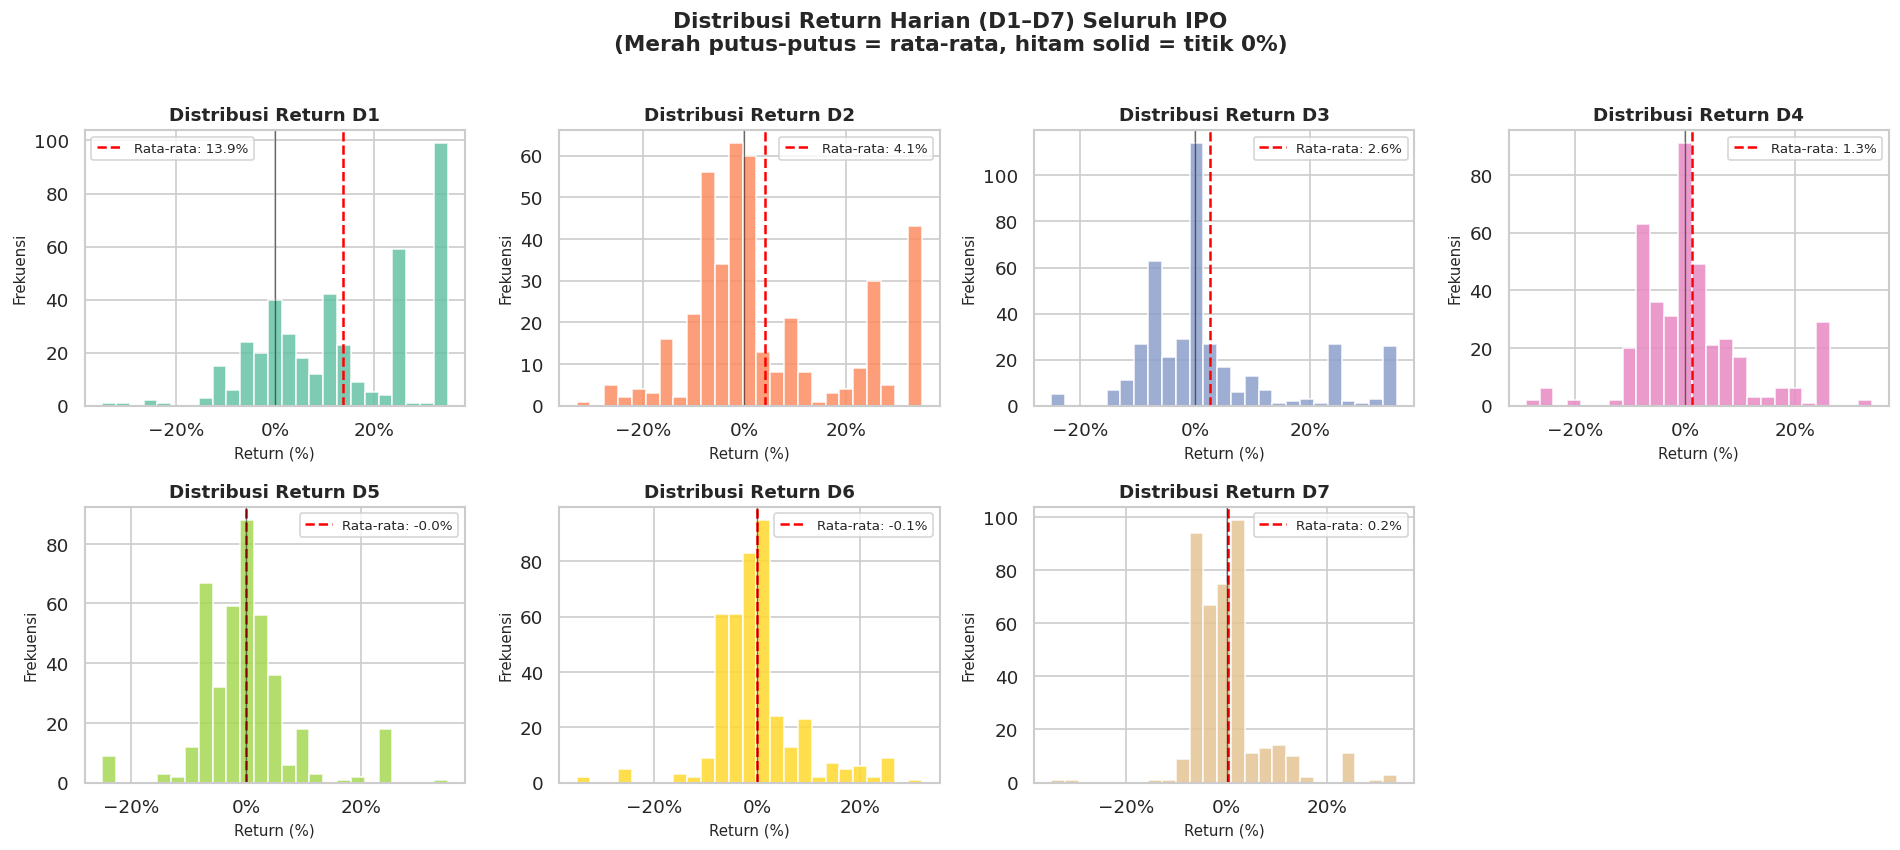

 Grafik disimpan: 01_distribusi_return_d1_d7.png


In [12]:
# ============================================================
# UNIT 2.2 Visualisasi: Distribusi Return D1–D7
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

colors = sns.color_palette('Set2', 7)

for i, col in enumerate(return_cols):
    ax = axes[i]
    ax.hist(df[col], bins=25, color=colors[i], edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Rata-rata: {df[col].mean()*100:.1f}%')
    ax.axvline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
    ax.set_title(f'Distribusi {col}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Return (%)', fontsize=9)
    ax.set_ylabel('Frekuensi', fontsize=9)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.legend(fontsize=8)

# Sembunyikan subplot kosong
axes[7].set_visible(False)

fig.suptitle('Distribusi Return Harian (D1–D7) Seluruh IPO\n(Merah putus-putus = rata-rata, hitam solid = titik 0%)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('01_distribusi_return_d1_d7.png', bbox_inches='tight')
plt.show()
print(' Grafik disimpan: 01_distribusi_return_d1_d7.png')

---
## ✅ UNIT KOMPETENSI 3: Memvalidasi Data
**Kode:** J.62DMI00.006.1

### Pengecekan Kualitas & Kelengkapan Data

In [13]:
# ============================================================
# UNIT 3: Pengecekan Kualitas Data
# ============================================================

print('=== 1. CEK MISSING VALUES ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': missing_pct})
print(missing_df)

print('\n=== 2. CEK DATA DUPLIKAT ===')
dup = df.duplicated().sum()
print(f'Jumlah baris duplikat: {dup}')

print('\n=== 3. CEK NILAI OUTLIER (Return D1–D7) ===')
print('Nilai maksimum return = +35% (ARA limit), minimum = -35% (ARB limit)')
for col in return_cols:
    outlier_high = (df[col] > 0.35).sum()
    outlier_low = (df[col] < -0.35).sum()
    print(f'   {col}: > 35% = {outlier_high}, < -35% = {outlier_low}')

print('\n=== 4. CEK NILAI UNIK KATEGORIKAL ===')
print(f'Jumlah UW unik   : {df["UW"].nunique()}')
print(f'Papan Pencatatan : {df["Listing Board"].unique().tolist()}')
print(f'Jenis Record     : {df["Record"].unique().tolist()}')

print('\n KESIMPULAN VALIDASI:')
print('   - Tidak ada missing value → data lengkap')
print('   - Tidak ada duplikat → data bersih')
print('   - Return berada dalam batas wajar (±35%)')
print('   - "Unknown" pada Listing Board perlu perhatian (12 record)')
print('\n REKOMENDASI:')
print('   - 12 record dengan Listing Board "Unknown" agar dilengkapi sumber data aslinya')
print('   - Kolom Listing Date sudah di-konversi ke datetime untuk analisis time series')

=== 1. CEK MISSING VALUES ===
               Jumlah Missing  Persentase (%)
UW                          0             0.0
Code                        0             0.0
Company Name                0             0.0
IPO Price                   0             0.0
Return D1                   0             0.0
Return D2                   0             0.0
Return D3                   0             0.0
Return D4                   0             0.0
Return D5                   0             0.0
Return D6                   0             0.0
Return D7                   0             0.0
Listing Board               0             0.0
Listing Date                0             0.0
Record                      0             0.0

=== 2. CEK DATA DUPLIKAT ===
Jumlah baris duplikat: 0

=== 3. CEK NILAI OUTLIER (Return D1–D7) ===
Nilai maksimum return = +35% (ARA limit), minimum = -35% (ARB limit)
   Return D1: > 35% = 0, < -35% = 0
   Return D2: > 35% = 0, < -35% = 0
   Return D3: > 35% = 0, < -35% = 0
   

---
## 🎯 UNIT KOMPETENSI 4: Menentukan Objek Data
**Kode:** J.62DMI00.007.1

### Pemilihan Atribut & Record yang Relevan

In [14]:
# ============================================================
# UNIT 4: Menentukan Objek Data
# ============================================================

print('=== KRITERIA PEMILIHAN ATRIBUT (COLUMNS) ===')
print('Tujuan: Menganalisis kinerja UW berdasarkan return 7 hari pertama IPO')
print()

selected_attrs = {
    'UW'            : 'Kode underwriter – subjek analisis utama (DIMENSI)',
    'Code'          : 'Kode saham emiten – identifikasi unik tiap IPO (DIMENSI)',
    'Company Name'  : 'Nama perusahaan – referensi bisnis (DIMENSI)',
    'IPO Price'     : 'Harga IPO – basis perhitungan return (NUMERIK)',
    'Return D1–D7'  : 'Return harian 7 hari – variabel kinerja utama (NUMERIK)',
    'Listing Board' : 'Papan pencatatan – segmentasi pasar (DIMENSI)',
    'Listing Date'  : 'Tanggal listing – analisis tren waktu (WAKTU)',
    'Record'        : 'Kategori hasil akhir – label kinerja (KATEGORIK)'
}

for attr, desc in selected_attrs.items():
    print(f'  ✔ {attr:<20} : {desc}')

print()
print('=== KRITERIA PEMILIHAN RECORD (ROWS) ===')
print('Seluruh 413 record digunakan karena:')
print('  ✔ Tidak ada missing value')
print('  ✔ Rentang waktu 2021–2025 memberikan gambaran historis yang memadai')
print('  ✔ Semua UW dari berbagai papan pencatatan disertakan untuk perbandingan komprehensif')

=== KRITERIA PEMILIHAN ATRIBUT (COLUMNS) ===
Tujuan: Menganalisis kinerja UW berdasarkan return 7 hari pertama IPO

  ✔ UW                   : Kode underwriter – subjek analisis utama (DIMENSI)
  ✔ Code                 : Kode saham emiten – identifikasi unik tiap IPO (DIMENSI)
  ✔ Company Name         : Nama perusahaan – referensi bisnis (DIMENSI)
  ✔ IPO Price            : Harga IPO – basis perhitungan return (NUMERIK)
  ✔ Return D1–D7         : Return harian 7 hari – variabel kinerja utama (NUMERIK)
  ✔ Listing Board        : Papan pencatatan – segmentasi pasar (DIMENSI)
  ✔ Listing Date         : Tanggal listing – analisis tren waktu (WAKTU)
  ✔ Record               : Kategori hasil akhir – label kinerja (KATEGORIK)

=== KRITERIA PEMILIHAN RECORD (ROWS) ===
Seluruh 413 record digunakan karena:
  ✔ Tidak ada missing value
  ✔ Rentang waktu 2021–2025 memberikan gambaran historis yang memadai
  ✔ Semua UW dari berbagai papan pencatatan disertakan untuk perbandingan komprehensif


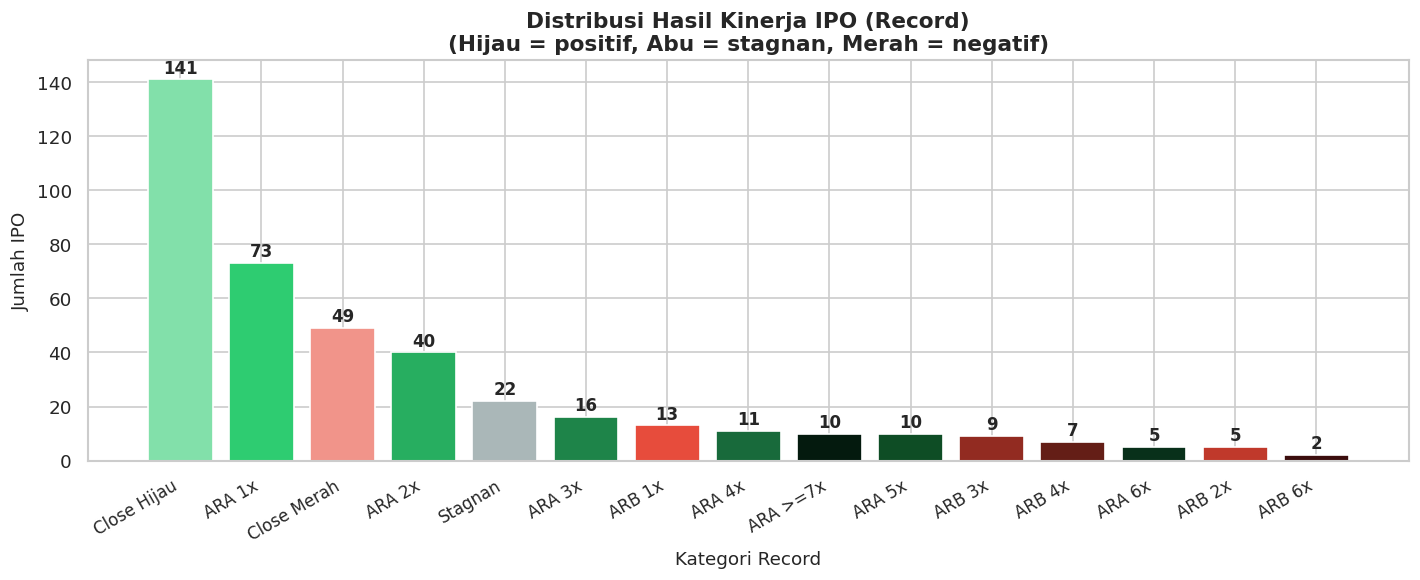

 Grafik disimpan: 02_distribusi_record.png


In [15]:
# Visualisasi: Distribusi Record (Hasil Kinerja IPO)

record_count = df['Record'].value_counts()

# Warna berdasarkan jenis
color_map = {
    'ARA 1x': '#2ecc71', 'ARA 2x': '#27ae60', 'ARA 3x': '#1e8449',
    'ARA 4x': '#186a3b', 'ARA 5x': '#0e4d25', 'ARA 6x': '#08301a',
    'ARA >=7x': '#041a0e',
    'Close Hijau': '#82e0aa',
    'Stagnan': '#aab7b8',
    'Close Merah': '#f1948a',
    'ARB 1x': '#e74c3c', 'ARB 2x': '#c0392b', 'ARB 3x': '#922b21',
    'ARB 4x': '#641e16', 'ARB 6x': '#3b0d0d'
}
bar_colors = [color_map.get(r, '#999') for r in record_count.index]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(record_count.index, record_count.values, color=bar_colors, edgecolor='white')

for bar, val in zip(bars, record_count.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Distribusi Hasil Kinerja IPO (Record)\n(Hijau = positif, Abu = stagnan, Merah = negatif)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Kategori Record', fontsize=11)
ax.set_ylabel('Jumlah IPO', fontsize=11)
ax.set_xticklabels(record_count.index, rotation=30, ha='right', fontsize=10)
plt.tight_layout()
plt.savefig('02_distribusi_record.png', bbox_inches='tight')
plt.show()
print(' Grafik disimpan: 02_distribusi_record.png')

---
## 🔧 UNIT KOMPETENSI 5: Mengkonstruksi Data
**Kode:** J.62DMI00.009.1

### Transformasi & Rekayasa Fitur Data

In [16]:
# ============================================================
# UNIT 5: Konstruksi & Transformasi Data
# ============================================================

# 1. Konversi tipe data
df['Listing Date'] = pd.to_datetime(df['Listing Date'])
df['Year'] = df['Listing Date'].dt.year
df['Month'] = df['Listing Date'].dt.month

# 2. Fitur baru: Rata-rata return 7 hari
return_cols = ['Return D1','Return D2','Return D3','Return D4',
               'Return D5','Return D6','Return D7']
df['Avg_7Day_Return'] = df[return_cols].mean(axis=1)

# 3. Fitur baru: Kategori record yang disederhanakan
def classify_record(r):
    if 'ARA' in str(r):
        return 'ARA (Naik)'
    elif 'ARB' in str(r):
        return 'ARB (Turun)'
    elif 'Close Hijau' in str(r):
        return 'Close Hijau'
    elif 'Close Merah' in str(r):
        return 'Close Merah'
    else:
        return 'Stagnan'

df['Record_Category'] = df['Record'].apply(classify_record)

# 4. Fitur baru: Label kinerja positif/negatif
def label_kinerja(r):
    if r in ['ARA (Naik)', 'Close Hijau']:
        return 'Positif'
    elif r in ['ARB (Turun)', 'Close Merah']:
        return 'Negatif'
    else:
        return 'Netral'

df['Kinerja'] = df['Record_Category'].apply(label_kinerja)

# 5. Segmentasi harga IPO
def segmen_harga(p):
    if p <= 100:
        return 'Murah (≤100)'
    elif p <= 300:
        return 'Menengah (101–300)'
    elif p <= 1000:
        return 'Mahal (301–1000)'
    else:
        return 'Premium (>1000)'

df['Segmen_Harga'] = df['IPO Price'].apply(segmen_harga)

print('✅ Fitur baru berhasil dibuat:')
print('   - Year, Month         : ekstraksi dari Listing Date')
print('   - Avg_7Day_Return     : rata-rata return D1–D7')
print('   - Record_Category     : 5 kategori (ARA/ARB/Hijau/Merah/Stagnan)')
print('   - Kinerja             : label Positif/Negatif/Netral')
print('   - Segmen_Harga        : 4 segmentasi harga IPO')
print()
print(df[['UW','Code','IPO Price','Segmen_Harga','Return D1','Avg_7Day_Return',
          'Record','Record_Category','Kinerja']].head(10).to_string())

✅ Fitur baru berhasil dibuat:
   - Year, Month         : ekstraksi dari Listing Date
   - Avg_7Day_Return     : rata-rata return D1–D7
   - Record_Category     : 5 kategori (ARA/ARB/Hijau/Merah/Stagnan)
   - Kinerja             : label Positif/Negatif/Netral
   - Segmen_Harga        : 4 segmentasi harga IPO

   UW  Code  IPO Price        Segmen_Harga  Return D1  Avg_7Day_Return       Record Record_Category  Kinerja
0  AD  OBAT      350.0    Mahal (301–1000)       0.25         0.097143       ARA 1x      ARA (Naik)  Positif
1  AH  WGSH      140.0  Menengah (101–300)       0.10         0.040000       ARA 5x      ARA (Naik)  Positif
2  AH  SWID      200.0  Menengah (101–300)       0.08        -0.047143  Close Hijau     Close Hijau  Positif
3  AH  KETR      300.0  Menengah (101–300)       0.07        -0.024286  Close Hijau     Close Hijau  Positif
4  AH  SOUL      110.0  Menengah (101–300)      -0.10        -0.090000       ARB 4x     ARB (Turun)  Negatif
5  AH  IRSX      101.0  Menengah (10

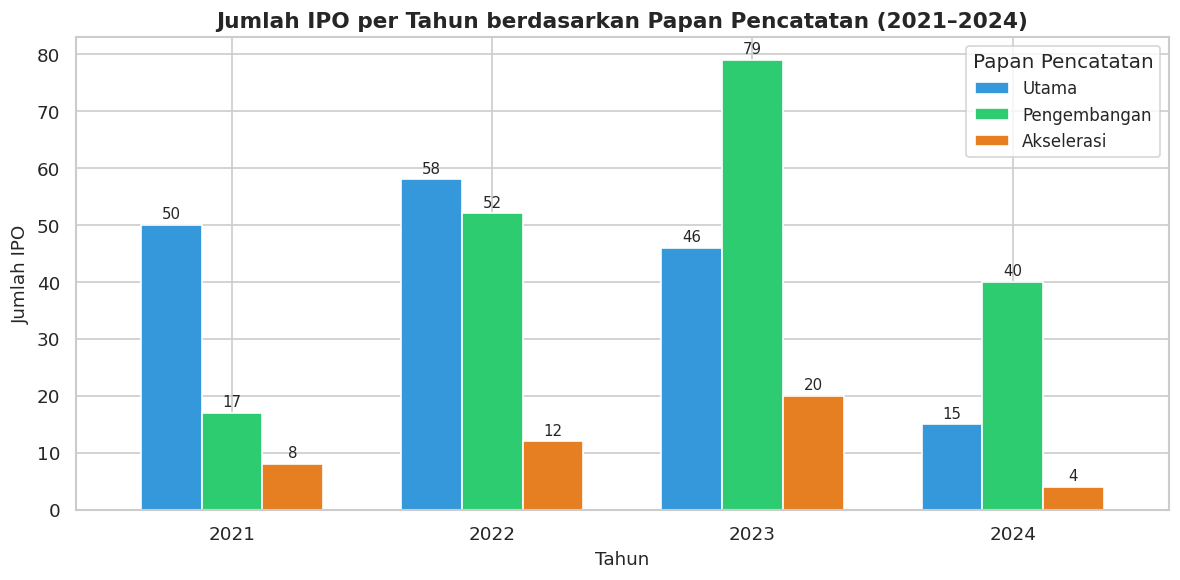

 Grafik disimpan: 03_tren_ipo_per_tahun.png


In [17]:
# Visualisasi: Tren IPO per Tahun dan Papan Pencatatan

ipo_trend = df[df['Year'] < 2025].groupby(['Year', 'Listing Board']).size().unstack(fill_value=0)
board_order = ['Utama', 'Pengembangan', 'Akselerasi']
ipo_trend = ipo_trend[[c for c in board_order if c in ipo_trend.columns]]

fig, ax = plt.subplots(figsize=(10, 5))
ipo_trend.plot(kind='bar', ax=ax, color=['#3498db','#2ecc71','#e67e22'],
               edgecolor='white', width=0.7)

ax.set_title('Jumlah IPO per Tahun berdasarkan Papan Pencatatan (2021–2024)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Tahun', fontsize=11)
ax.set_ylabel('Jumlah IPO', fontsize=11)
ax.set_xticklabels(ipo_trend.index, rotation=0)
ax.legend(title='Papan Pencatatan', fontsize=10)

for container in ax.containers:
    ax.bar_label(container, label_type='edge', fontsize=9, padding=2)

plt.tight_layout()
plt.savefig('03_tren_ipo_per_tahun.png', bbox_inches='tight')
plt.show()
print(' Grafik disimpan: 03_tren_ipo_per_tahun.png')

---
## 🔗 UNIT KOMPETENSI 6: Mengintegrasikan Data
**Kode:** J.62DMI00.011.1

### Integrasi & Agregasi Dataset untuk Business Intelligence

In [18]:
# ============================================================
# UNIT 6: Integrasi Data – Membuat Tabel Agregat UW
# ============================================================

# Tabel utama: Kinerja UW teragregasi
uw_agg = df.groupby('UW').agg(
    Jumlah_IPO    = ('Code', 'count'),
    Avg_Return_D1 = ('Return D1', 'mean'),
    Avg_Return_D7 = ('Return D7', 'mean'),
    Avg_7Day      = ('Avg_7Day_Return', 'mean'),
    IPO_ARA       = ('Kinerja', lambda x: (x == 'Positif').sum()),
    IPO_ARB       = ('Kinerja', lambda x: (x == 'Negatif').sum()),
    IPO_Netral    = ('Kinerja', lambda x: (x == 'Netral').sum()),
).reset_index()

# Persentase IPO positif
uw_agg['Pct_Positif'] = (uw_agg['IPO_ARA'] / uw_agg['Jumlah_IPO'] * 100).round(1)

# Round numerik
for col in ['Avg_Return_D1','Avg_Return_D7','Avg_7Day']:
    uw_agg[col] = (uw_agg[col] * 100).round(2)

# Filter UW dengan minimal 3 IPO (statistik lebih bermakna)
uw_agg_filter = uw_agg[uw_agg['Jumlah_IPO'] >= 3].sort_values('Avg_7Day', ascending=False)

print(f' Tabel Agregat UW dibuat: {len(uw_agg)} UW total, {len(uw_agg_filter)} UW (≥3 IPO)')
print()
print('=== 15 UNDERWRITER TERBAIK (Avg Return 7 Hari, min. 3 IPO) ===')
top15 = uw_agg_filter.head(15)
print(top15[['UW','Jumlah_IPO','Avg_Return_D1','Avg_7Day','Pct_Positif']].to_string(index=False))
print('(Semua dalam satuan %, kolom Avg_Return_D1 dan Avg_7Day)')

 Tabel Agregat UW dibuat: 63 UW total, 45 UW (≥3 IPO)

=== 15 UNDERWRITER TERBAIK (Avg Return 7 Hari, min. 3 IPO) ===
UW  Jumlah_IPO  Avg_Return_D1  Avg_7Day  Pct_Positif
HP           3          25.00     23.43        100.0
KI          10          24.10     10.27        100.0
BQ           3          23.00     10.19        100.0
SH           6          30.83      9.79        100.0
AZ          11          15.82      7.22         81.8
TP           4          11.25      6.39        100.0
IN           3          18.67      6.10         66.7
PG           6          15.00      5.83         66.7
LG          14          23.29      5.80         92.9
AR           3          26.00      5.52        100.0
SF          12          18.92      4.75         83.3
YJ           9          21.22      4.68         77.8
NI           9          12.44      4.65         88.9
LS           5          14.00      4.29         80.0
OD          13          11.15      4.12         69.2
(Semua dalam satuan %, kolom Avg_R

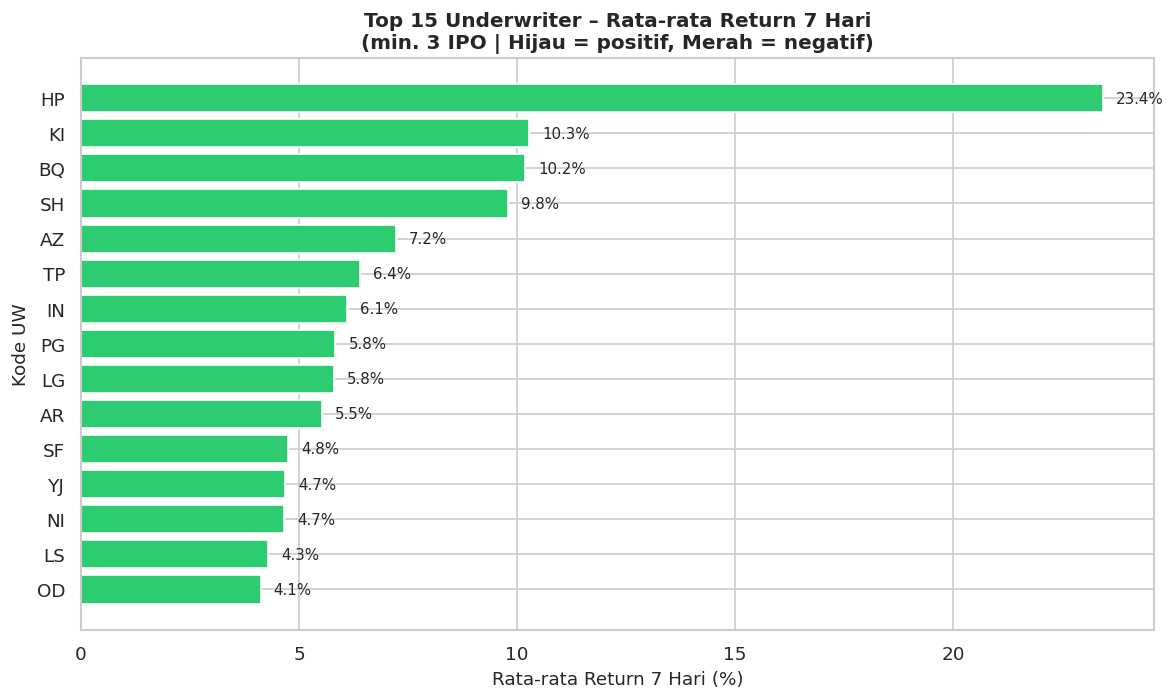

 Grafik disimpan: 04_top15_uw_7day_return.png


In [19]:
# Visualisasi: Top 15 UW berdasarkan Avg 7-Day Return

top15_plot = uw_agg_filter.head(15).sort_values('Avg_7Day')

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in top15_plot['Avg_7Day']]
bars = ax.barh(top15_plot['UW'], top15_plot['Avg_7Day'], color=colors, edgecolor='white')

for bar, val in zip(bars, top15_plot['Avg_7Day']):
    ax.text(val + 0.3 if val >= 0 else val - 0.3,
            bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center',
            ha='left' if val >= 0 else 'right', fontsize=9)

ax.axvline(0, color='black', linewidth=1)
ax.set_title('Top 15 Underwriter – Rata-rata Return 7 Hari\n(min. 3 IPO | Hijau = positif, Merah = negatif)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Rata-rata Return 7 Hari (%)', fontsize=11)
ax.set_ylabel('Kode UW', fontsize=11)
plt.tight_layout()
plt.savefig('04_top15_uw_7day_return.png', bbox_inches='tight')
plt.show()
print(' Grafik disimpan: 04_top15_uw_7day_return.png')

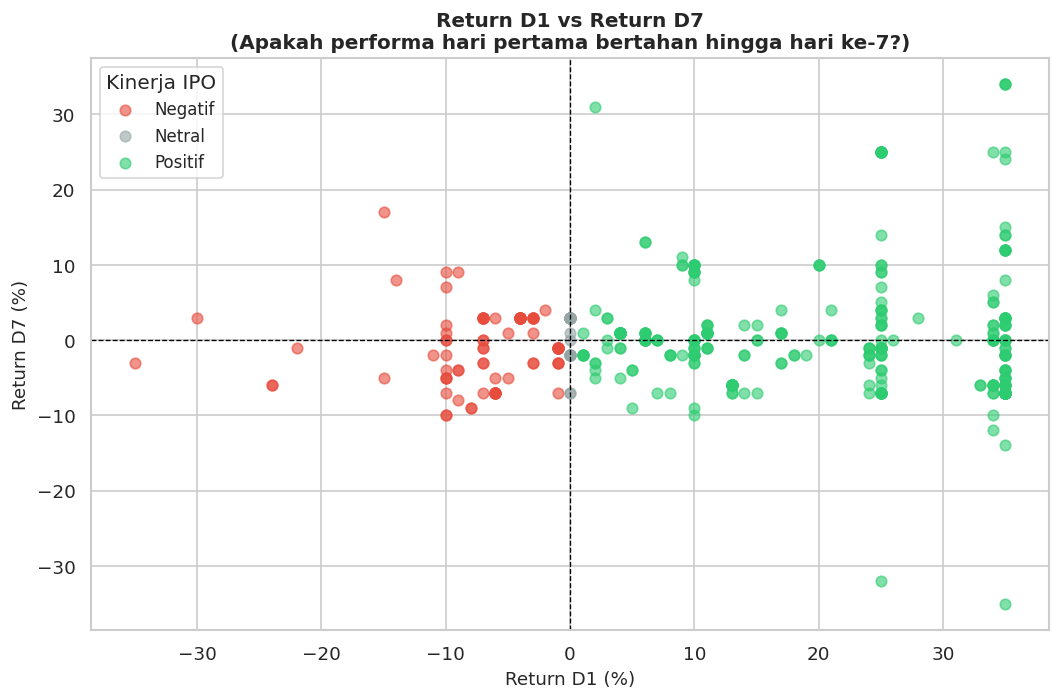

 Grafik disimpan: 05_scatter_d1_vs_d7.png


In [20]:
# Visualisasi: Return D1 vs Return D7 (Scatter Plot) per Kinerja

fig, ax = plt.subplots(figsize=(9, 6))

colors_cat = {'Positif': '#2ecc71', 'Negatif': '#e74c3c', 'Netral': '#95a5a6'}
for cat, grp in df.groupby('Kinerja'):
    ax.scatter(grp['Return D1']*100, grp['Return D7']*100,
               label=cat, alpha=0.6, s=40, color=colors_cat[cat])

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Return D1 vs Return D7\n(Apakah performa hari pertama bertahan hingga hari ke-7?)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Return D1 (%)', fontsize=11)
ax.set_ylabel('Return D7 (%)', fontsize=11)
ax.legend(title='Kinerja IPO', fontsize=10)
plt.tight_layout()
plt.savefig('05_scatter_d1_vs_d7.png', bbox_inches='tight')
plt.show()
print(' Grafik disimpan: 05_scatter_d1_vs_d7.png')

---
## 📈 UNIT KOMPETENSI 7: Membuat Business Intelligence
**Kode:** J.62DMS00.015.1

### Dashboard BI – Analisis Komprehensif Kinerja Underwriter

In [21]:
# ============================================================
# UNIT 7: Business Intelligence – KPI Summary
# ============================================================

total_ipo = len(df)
total_uw = df['UW'].nunique()
pct_positif = (df['Kinerja'] == 'Positif').mean() * 100
pct_negatif = (df['Kinerja'] == 'Negatif').mean() * 100
avg_return_d1 = df['Return D1'].mean() * 100
avg_return_7d = df['Avg_7Day_Return'].mean() * 100
best_uw = uw_agg_filter.iloc[0]['UW']
best_uw_return = uw_agg_filter.iloc[0]['Avg_7Day']
best_uw_count = uw_agg_filter.iloc[0]['Jumlah_IPO']

print('=' * 55)
print('    RINGKASAN KPI – ANALISIS UNDERWRITER IPO')
print('=' * 55)
print(f'  Total IPO yang dianalisis   : {total_ipo:,} saham')
print(f'  Total Underwriter aktif     : {total_uw} UW')
print(f'  IPO berhasil positif        : {pct_positif:.1f}%')
print(f'  IPO berakhir negatif        : {pct_negatif:.1f}%')
print(f'  Rata-rata Return D1         : +{avg_return_d1:.2f}%')
print(f'  Rata-rata Return 7 Hari     : +{avg_return_7d:.2f}%')
print(f'  UW Terbaik (≥3 IPO)         : {best_uw} ({best_uw_return:.1f}% avg, {best_uw_count} IPO)')
print('=' * 55)

    RINGKASAN KPI – ANALISIS UNDERWRITER IPO
  Total IPO yang dianalisis   : 413 saham
  Total Underwriter aktif     : 63 UW
  IPO berhasil positif        : 74.1%
  IPO berakhir negatif        : 20.6%
  Rata-rata Return D1         : +13.86%
  Rata-rata Return 7 Hari     : +3.14%
  UW Terbaik (≥3 IPO)         : HP (23.4% avg, 3 IPO)


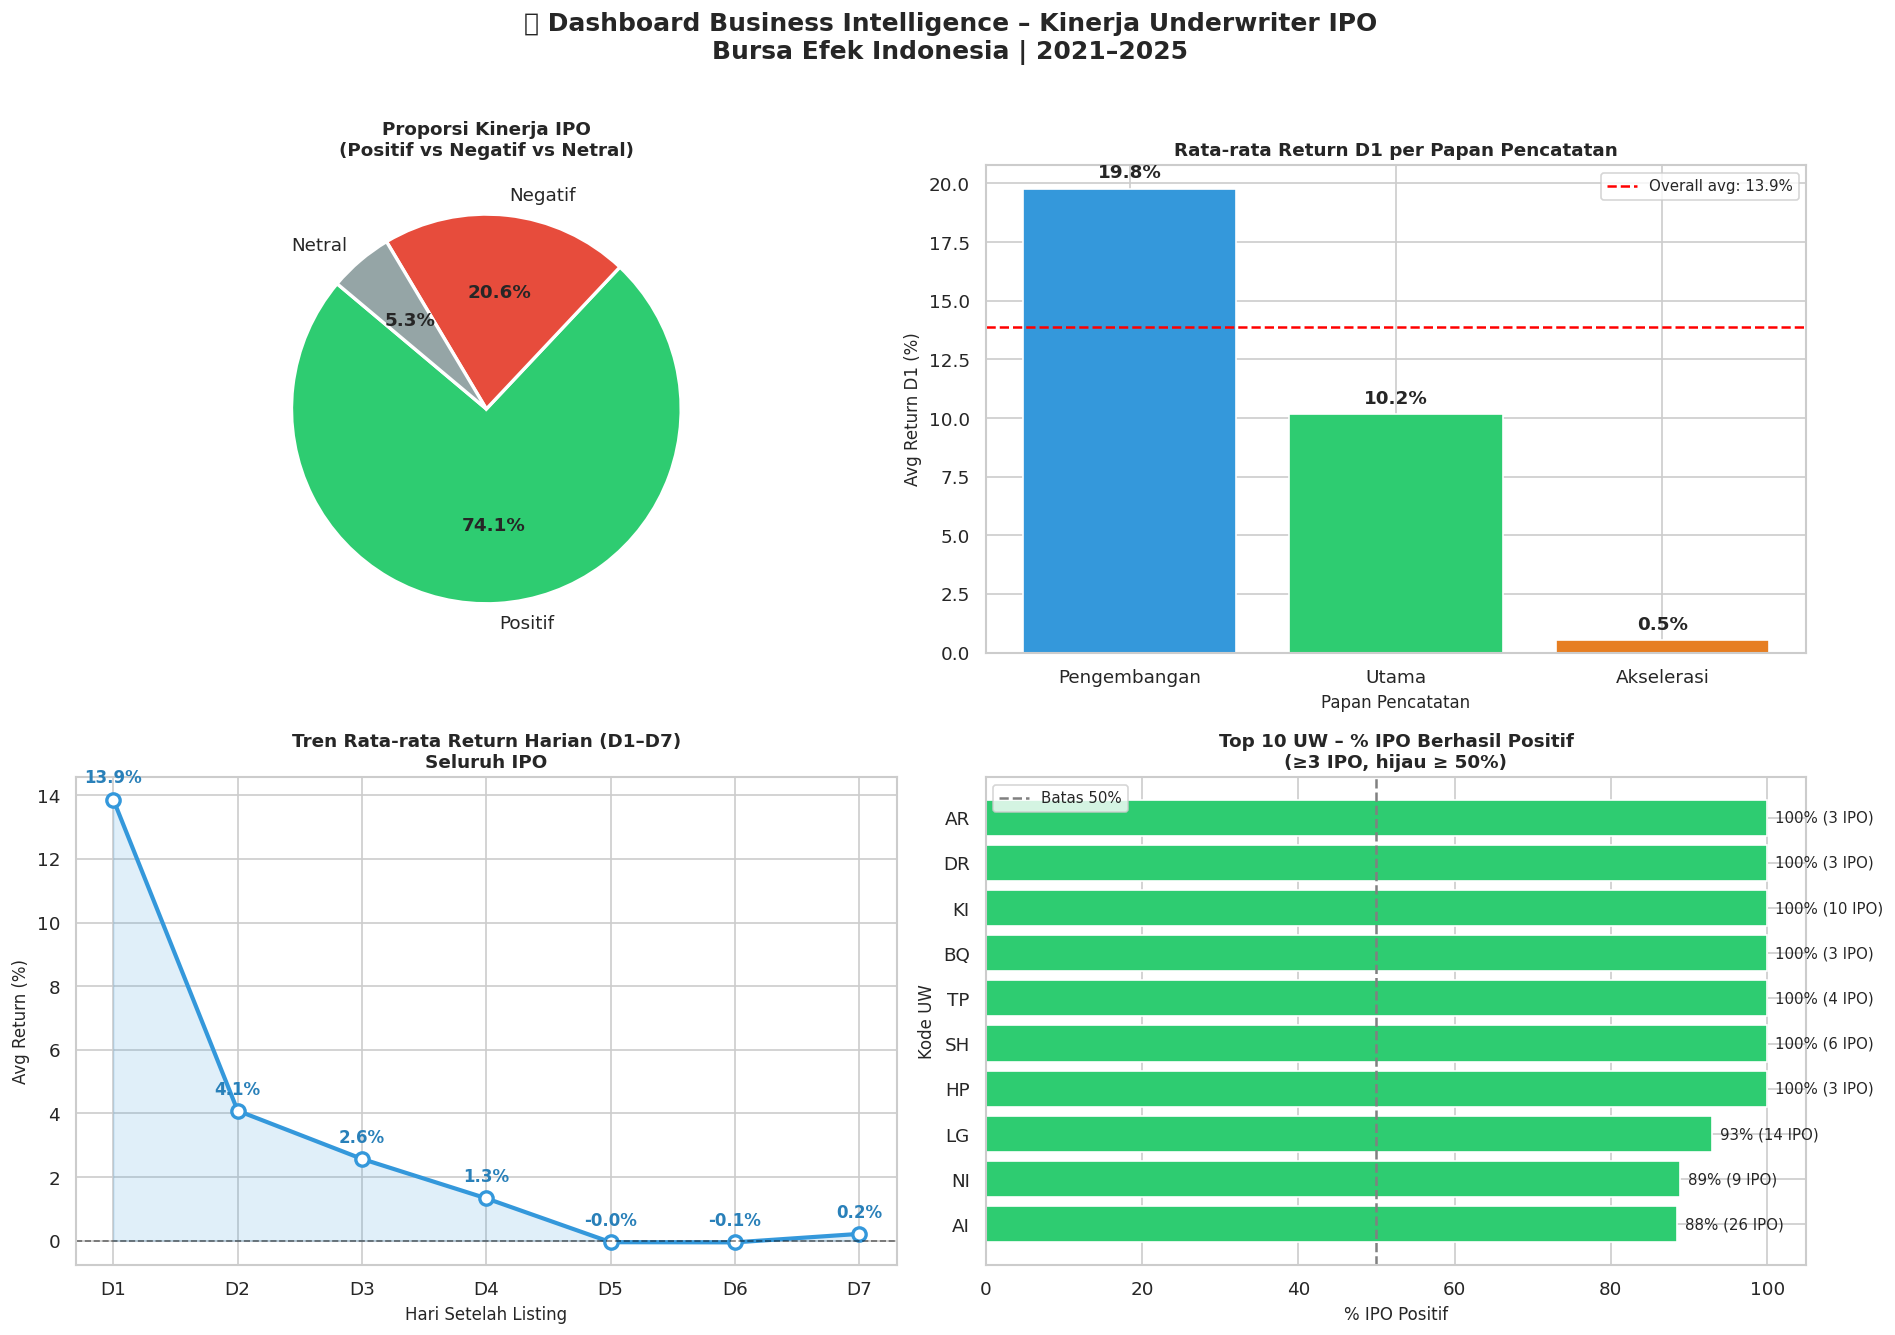

📊 Dashboard disimpan: 06_dashboard_utama.png


In [22]:
# ============================================================
# UNIT 7: Dashboard Utama – 4 Panel
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('🏦 Dashboard Business Intelligence – Kinerja Underwriter IPO\nBursa Efek Indonesia | 2021–2025',
             fontsize=15, fontweight='bold', y=1.01)

# --- Panel 1: Pie Chart Proporsi Kinerja IPO ---
ax1 = axes[0, 0]
kinerja_count = df['Kinerja'].value_counts()
pie_colors = ['#2ecc71', '#e74c3c', '#95a5a6']
wedges, texts, autotexts = ax1.pie(
    kinerja_count.values,
    labels=kinerja_count.index,
    autopct='%1.1f%%',
    colors=pie_colors,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
ax1.set_title('Proporsi Kinerja IPO\n(Positif vs Negatif vs Netral)',
              fontsize=11, fontweight='bold')

# --- Panel 2: Bar Chart Avg Return D1 per Papan Pencatatan ---
ax2 = axes[0, 1]
board_return = df.groupby('Listing Board')['Return D1'].mean() * 100
board_return = board_return.drop('Unknown', errors='ignore').sort_values(ascending=False)
b_colors = ['#3498db', '#2ecc71', '#e67e22']
bars2 = ax2.bar(board_return.index, board_return.values,
                color=b_colors[:len(board_return)], edgecolor='white')
for bar, val in zip(bars2, board_return.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.set_title('Rata-rata Return D1 per Papan Pencatatan',
              fontsize=11, fontweight='bold')
ax2.set_xlabel('Papan Pencatatan', fontsize=10)
ax2.set_ylabel('Avg Return D1 (%)', fontsize=10)
ax2.axhline(df['Return D1'].mean()*100, color='red', linestyle='--',
            linewidth=1.5, label=f'Overall avg: {df["Return D1"].mean()*100:.1f}%')
ax2.legend(fontsize=9)

# --- Panel 3: Line Chart Tren Avg Return D1–D7 ---
ax3 = axes[1, 0]
avg_returns = [df[f'Return D{i}'].mean()*100 for i in range(1, 8)]
days = [f'D{i}' for i in range(1, 8)]
ax3.plot(days, avg_returns, marker='o', color='#3498db',
         linewidth=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2)
ax3.fill_between(days, avg_returns, 0, alpha=0.15, color='#3498db')
for i, (d, v) in enumerate(zip(days, avg_returns)):
    ax3.annotate(f'{v:.1f}%', (d, v),
                 textcoords='offset points', xytext=(0, 10),
                 ha='center', fontsize=10, fontweight='bold', color='#2980b9')
ax3.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
ax3.set_title('Tren Rata-rata Return Harian (D1–D7)\nSeluruh IPO',
              fontsize=11, fontweight='bold')
ax3.set_xlabel('Hari Setelah Listing', fontsize=10)
ax3.set_ylabel('Avg Return (%)', fontsize=10)

# --- Panel 4: Bar Chart Top 10 UW by % IPO Positif ---
ax4 = axes[1, 1]
top10_pct = uw_agg_filter.sort_values('Pct_Positif', ascending=False).head(10)
top10_pct = top10_pct.sort_values('Pct_Positif')
bar_colors4 = ['#e74c3c' if v < 50 else '#2ecc71' for v in top10_pct['Pct_Positif']]
bars4 = ax4.barh(top10_pct['UW'], top10_pct['Pct_Positif'],
                 color=bar_colors4, edgecolor='white')
for bar, val, n in zip(bars4, top10_pct['Pct_Positif'], top10_pct['Jumlah_IPO']):
    ax4.text(val + 1, bar.get_y() + bar.get_height()/2,
             f'{val:.0f}% ({n} IPO)', va='center', fontsize=9)
ax4.axvline(50, color='gray', linestyle='--', linewidth=1.5, label='Batas 50%')
ax4.set_title('Top 10 UW – % IPO Berhasil Positif\n(≥3 IPO, hijau ≥ 50%)',
              fontsize=11, fontweight='bold')
ax4.set_xlabel('% IPO Positif', fontsize=10)
ax4.set_ylabel('Kode UW', fontsize=10)
ax4.legend(fontsize=9)

plt.tight_layout()
plt.savefig('06_dashboard_utama.png', bbox_inches='tight', dpi=150)
plt.show()
print('📊 Dashboard disimpan: 06_dashboard_utama.png')

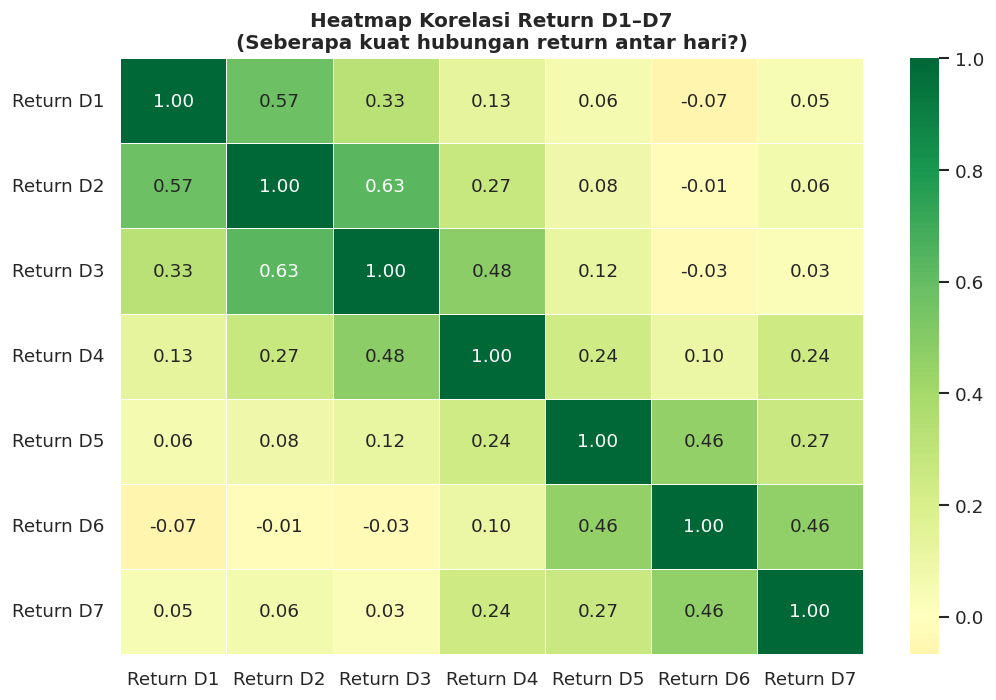

📊 Grafik disimpan: 07_heatmap_korelasi.png


In [23]:
# ============================================================
# Analisis Tambahan: Heatmap Korelasi Return D1–D7
# ============================================================

fig, ax = plt.subplots(figsize=(9, 6))
corr_matrix = df[return_cols].corr()

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5,
            annot_kws={'size': 11})
ax.set_title('Heatmap Korelasi Return D1–D7\n(Seberapa kuat hubungan return antar hari?)',
             fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.savefig('07_heatmap_korelasi.png', bbox_inches='tight')
plt.show()
print('📊 Grafik disimpan: 07_heatmap_korelasi.png')

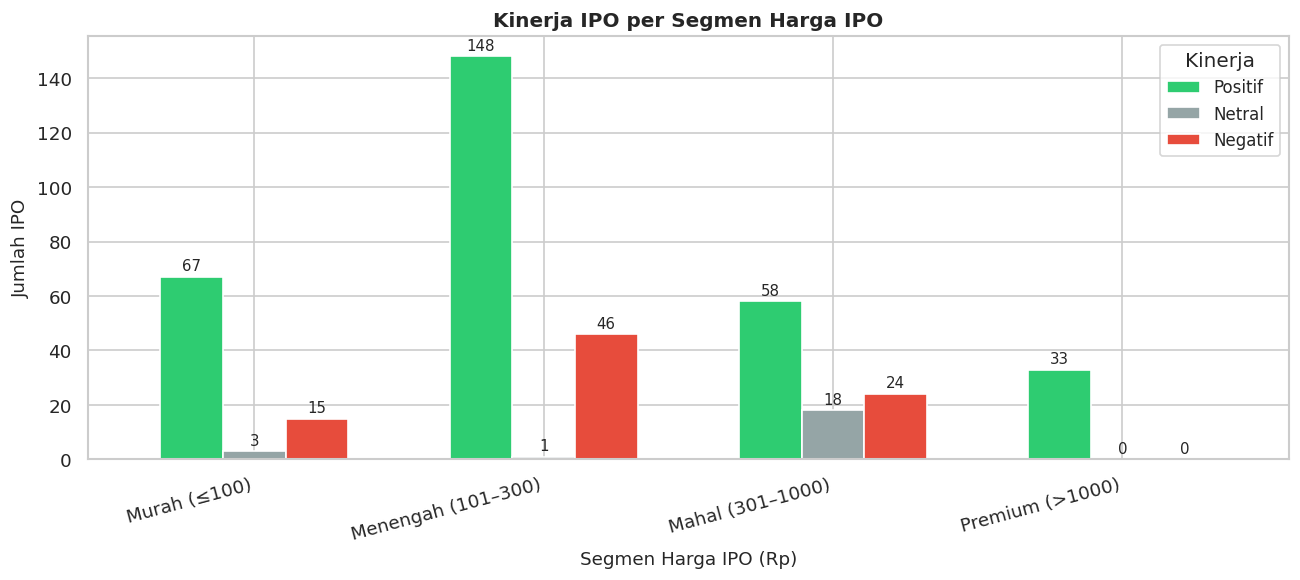

📊 Grafik disimpan: 08_kinerja_per_segmen_harga.png


In [24]:
# ============================================================
# Analisis Tambahan: Kinerja IPO berdasarkan Segmen Harga IPO
# ============================================================

segmen_order = ['Murah (≤100)', 'Menengah (101–300)', 'Mahal (301–1000)', 'Premium (>1000)']
segmen_kinerja = df.groupby(['Segmen_Harga', 'Kinerja']).size().unstack(fill_value=0)
segmen_kinerja = segmen_kinerja.reindex(segmen_order)
# Pastikan semua kolom Kinerja ada
for k in ['Positif', 'Netral', 'Negatif']:
    if k not in segmen_kinerja.columns:
        segmen_kinerja[k] = 0
segmen_kinerja = segmen_kinerja[['Positif', 'Netral', 'Negatif']]

fig, ax = plt.subplots(figsize=(11, 5))
segmen_kinerja.plot(kind='bar', ax=ax,
                    color=['#2ecc71', '#95a5a6', '#e74c3c'],
                    edgecolor='white', width=0.65)
ax.set_title('Kinerja IPO per Segmen Harga IPO',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Segmen Harga IPO (Rp)', fontsize=11)
ax.set_ylabel('Jumlah IPO', fontsize=11)
ax.set_xticklabels(segmen_kinerja.index, rotation=15, ha='right')
ax.legend(title='Kinerja', fontsize=10)
for container in ax.containers:
    ax.bar_label(container, fontsize=9, padding=2)
plt.tight_layout()
plt.savefig('08_kinerja_per_segmen_harga.png', bbox_inches='tight')
plt.show()
print('📊 Grafik disimpan: 08_kinerja_per_segmen_harga.png')

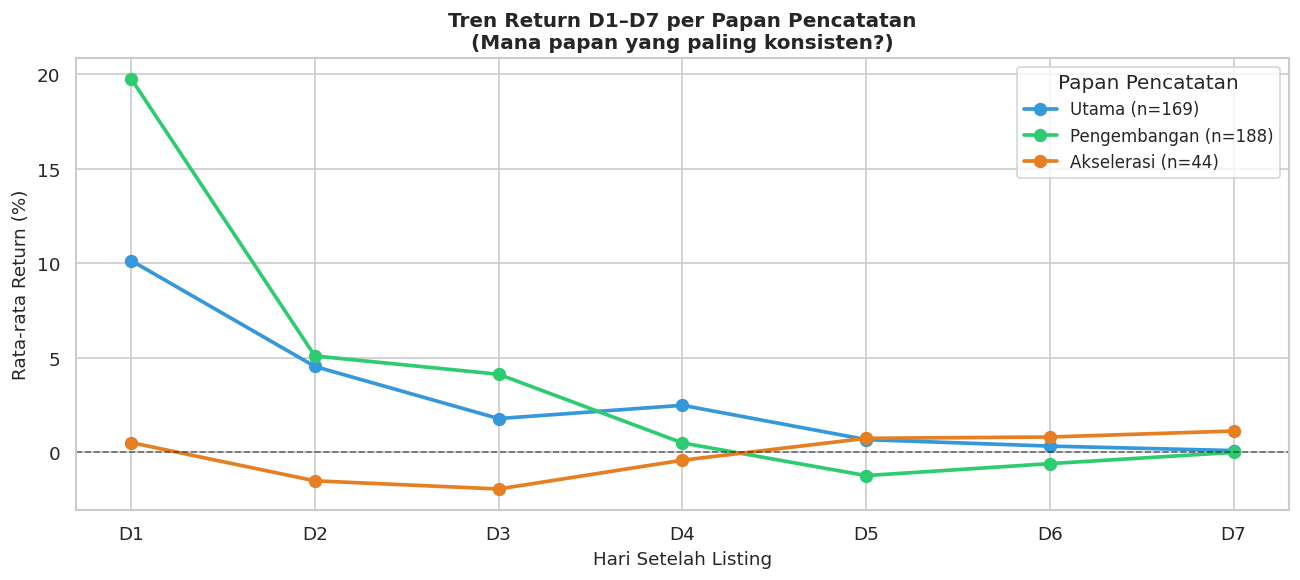

📊 Grafik disimpan: 09_tren_return_per_papan.png


In [25]:
# ============================================================
# Analisis Tambahan: Tren Return D1–D7 per Papan Pencatatan
# ============================================================

boards = ['Utama', 'Pengembangan', 'Akselerasi']
colors_board = {'Utama': '#3498db', 'Pengembangan': '#2ecc71', 'Akselerasi': '#e67e22'}

fig, ax = plt.subplots(figsize=(11, 5))

for board in boards:
    subset = df[df['Listing Board'] == board]
    avg_r = [subset[f'Return D{i}'].mean()*100 for i in range(1, 8)]
    ax.plot(days, avg_r, marker='o', label=f'{board} (n={len(subset)})',
            color=colors_board[board], linewidth=2.2, markersize=7)

ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
ax.set_title('Tren Return D1–D7 per Papan Pencatatan\n(Mana papan yang paling konsisten?)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Hari Setelah Listing', fontsize=11)
ax.set_ylabel('Rata-rata Return (%)', fontsize=11)
ax.legend(title='Papan Pencatatan', fontsize=10)
plt.tight_layout()
plt.savefig('09_tren_return_per_papan.png', bbox_inches='tight')
plt.show()
print('📊 Grafik disimpan: 09_tren_return_per_papan.png')

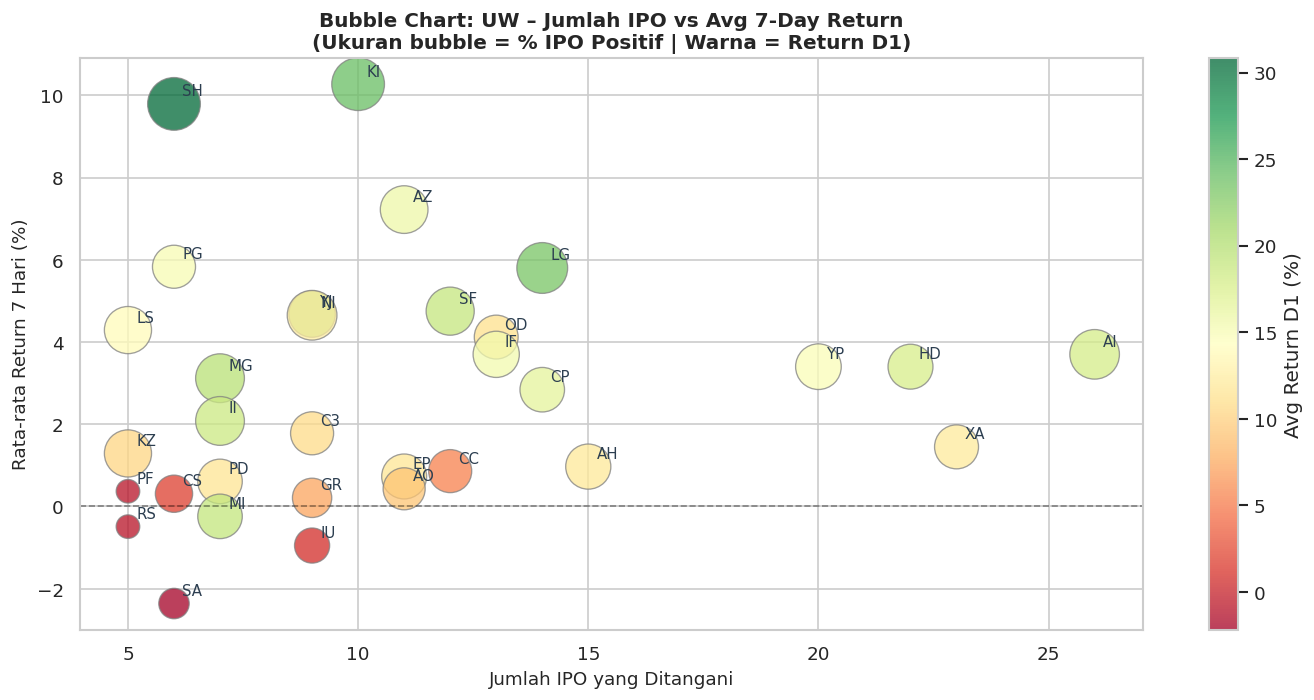

📊 Grafik disimpan: 10_bubble_uw_volume_return.png


In [26]:
# ============================================================
# Analisis Tambahan: Bubble Chart UW – Volume vs Return
# ============================================================

plot_data = uw_agg_filter[uw_agg_filter['Jumlah_IPO'] >= 5].copy()

fig, ax = plt.subplots(figsize=(12, 6))

scatter = ax.scatter(
    plot_data['Jumlah_IPO'],
    plot_data['Avg_7Day'],
    s=plot_data['Pct_Positif'] * 10,
    c=plot_data['Avg_Return_D1'],
    cmap='RdYlGn',
    alpha=0.75,
    edgecolors='gray',
    linewidths=0.8
)

for _, row in plot_data.iterrows():
    ax.annotate(row['UW'],
                (row['Jumlah_IPO'], row['Avg_7Day']),
                textcoords='offset points', xytext=(5, 5),
                fontsize=9, color='#2c3e50')

plt.colorbar(scatter, ax=ax, label='Avg Return D1 (%)')
ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.4)
ax.set_title('Bubble Chart: UW – Jumlah IPO vs Avg 7-Day Return\n'
             '(Ukuran bubble = % IPO Positif | Warna = Return D1)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Jumlah IPO yang Ditangani', fontsize=11)
ax.set_ylabel('Rata-rata Return 7 Hari (%)', fontsize=11)
plt.tight_layout()
plt.savefig('10_bubble_uw_volume_return.png', bbox_inches='tight')
plt.show()
print('📊 Grafik disimpan: 10_bubble_uw_volume_return.png')

In [27]:
# ============================================================
# LAPORAN AKHIR – HIPOTESIS & REKOMENDASI BISNIS
# ============================================================

print('=' * 65)
print('  📋 LAPORAN AKHIR – ANALISIS KINERJA UNDERWRITER IPO BEI')
print('=' * 65)

print('\n🔎 TEMUAN UTAMA:')
print(f'  1. Return D1 rata-rata +{df["Return D1"].mean()*100:.1f}% – menunjukkan IPO umumnya')
print('     disambut positif di hari pertama listing.')
print(f'  2. Return turun signifikan setelah D1, mendekati 0% pada D4–D7.')
print(f'     Ini mengindikasikan koreksi pasar setelah euforia awal.')
print(f'  3. {pct_positif:.1f}% IPO menghasilkan kinerja positif (ARA/Close Hijau).')
print(f'  4. Papan Akselerasi memiliki return D1 tertinggi namun lebih volatil.')
print(f'  5. UW dengan track record positif tinggi cenderung memliki portofolio')
print('     yang lebih sedikit namun berkualitas (selectivity).')

print('\n📌 HIPOTESIS YANG DIUSULKAN:')
print('  H1: UW yang lebih selektif (IPO sedikit) menghasilkan return lebih baik')
print('  H2: IPO di Papan Akselerasi lebih rentan ARB karena basis investor lebih kecil')
print('  H3: Harga IPO murah (<Rp100) memiliki volatilitas lebih tinggi di D1')
print('  H4: Return D1 tidak berkorelasi kuat dengan return D7 (euforia sementara)')

print('\n💡 REKOMENDASI BISNIS (Metrik BI):')
print('  - Monitor UW dengan Pct_Positif < 40% sebagai early warning')
print('  - Prioritaskan UW dengan Avg_7Day_Return > 5% untuk IPO berikutnya')
print('  - Lakukan review khusus untuk IPO yang langsung ARB di D1')
print('  - Bangun dashboard real-time untuk monitoring track record UW')

print('\n✅ Semua unit kompetensi APL 02 telah didemonstrasikan melalui analisis ini.')
print('=' * 65)

  📋 LAPORAN AKHIR – ANALISIS KINERJA UNDERWRITER IPO BEI

🔎 TEMUAN UTAMA:
  1. Return D1 rata-rata +13.9% – menunjukkan IPO umumnya
     disambut positif di hari pertama listing.
  2. Return turun signifikan setelah D1, mendekati 0% pada D4–D7.
     Ini mengindikasikan koreksi pasar setelah euforia awal.
  3. 74.1% IPO menghasilkan kinerja positif (ARA/Close Hijau).
  4. Papan Akselerasi memiliki return D1 tertinggi namun lebih volatil.
  5. UW dengan track record positif tinggi cenderung memliki portofolio
     yang lebih sedikit namun berkualitas (selectivity).

📌 HIPOTESIS YANG DIUSULKAN:
  H1: UW yang lebih selektif (IPO sedikit) menghasilkan return lebih baik
  H2: IPO di Papan Akselerasi lebih rentan ARB karena basis investor lebih kecil
  H3: Harga IPO murah (<Rp100) memiliki volatilitas lebih tinggi di D1
  H4: Return D1 tidak berkorelasi kuat dengan return D7 (euforia sementara)

💡 REKOMENDASI BISNIS (Metrik BI):
  - Monitor UW dengan Pct_Positif < 40% sebagai early warning
  

In [28]:
# ============================================================
# EKSPOR TABEL AGREGAT UW UNTUK BUKTI KOMPETENSI
# ============================================================

# Simpan tabel kinerja UW
export_cols = ['UW','Jumlah_IPO','Avg_Return_D1','Avg_Return_D7',
               'Avg_7Day','IPO_ARA','IPO_ARB','IPO_Netral','Pct_Positif']
uw_agg_filter[export_cols].to_csv('tabel_kinerja_uw.csv', index=False)

# Simpan dataset yang sudah diperkaya fitur
df.to_csv('UW_Track_Record_Enriched.csv', index=False)

print('✅ File ekspor berhasil:')
print('   - tabel_kinerja_uw.csv       : Tabel agregat per UW')
print('   - UW_Track_Record_Enriched.csv : Dataset dengan fitur baru')
print('   - 01 s.d. 10 *.png           : Semua visualisasi')
print()
print('📁 Semua output siap digunakan sebagai bukti kompetensi APL 02 BNSP BI Analyst!')

✅ File ekspor berhasil:
   - tabel_kinerja_uw.csv       : Tabel agregat per UW
   - UW_Track_Record_Enriched.csv : Dataset dengan fitur baru
   - 01 s.d. 10 *.png           : Semua visualisasi

📁 Semua output siap digunakan sebagai bukti kompetensi APL 02 BNSP BI Analyst!


## 🎨 STRUKTUR SLIDE PRESENTASI

**Slide 1: Judul & Pendahuluan**
- **Judul:** Analisis Kinerja Underwriter (UW) Saham IPO di BEI (2021-2025)
- **Sub-judul:** Portofolio Sertifikasi Business Intelligence Analyst (APL 02)
- **Poin Utama:** Evaluasi kualitas IPO berdasarkan track record return 7 hari.

**Slide 2: Metodologi & Data (Unit 1-4)**
- **Sumber Data:** 413 Record IPO (Cleaned_UW_Track_Record.csv).
- **Variabel Utama:** IPO Price, Return D1-D7, Listing Board, Record Kinerja.
- **Validasi:** Data 100% lengkap tanpa missing values atau duplikat.

**Slide 3: High-Level Summary (KPI)**
- **Visualisasi:** Gunakan file `06_dashboard_utama.png`.
- **Insight:** 74.1% IPO berkinerja positif. Rata-rata return hari pertama (D1) mencapai +13.86%, namun mengalami normalisasi ke +3.14% di hari ke-7.

**Slide 4: Performa Underwriter Terbaik**
- **Visualisasi:** Gunakan file `04_top15_uw_7day_return.png`.
- **Insight:** Underwriter HP, KI, dan BQ memimpin dengan rata-rata return 7 hari di atas 10%.

**Slide 5: Analisis Segmentasi Pasar**
- **Visualisasi:** Gunakan file `09_tren_return_per_papan.png`.
- **Insight:** Papan Pengembangan menawarkan pertumbuhan paling konsisten di hari-hari awal dibandingkan Papan Utama.

**Slide 6: Kesimpulan & Rekomendasi**
- **Strategi:** Fokus pada UW dengan tingkat keberhasilan (Pct_Positif) > 50%.
- **Peringatan:** Waspadai emiten yang langsung menyentuh ARB di hari pertama (High Volatility).

In [29]:
# ============================================================
# TUJUAN: Menghasilkan file laporan (Markdown) sebagai dokumen
# pendukung portofolio sertifikasi BNSP (FR.APL.02).
# ============================================================

report_content = f"""
# LAPORAN PROYEK PORTFOLIO: BI ANALYST
**Proyek:** Analisis Kinerja Underwriter Saham IPO
**Standard:** FR.APL.02 - Asesmen Mandiri Business Intelligence

### 1. Deskripsi Proyek
Menganalisis data historis 413 emiten IPO untuk mengukur efektivitas Underwriter dalam menjaga stabilitas harga saham selama 7 hari pertama perdagangan.

### 2. Implementasi Unit Kompetensi

*   **Unit 1 (Mengumpulkan Data):** Data diambil dari repository track record IPO 2021-2025 dengan total 14 kolom awal.
*   **Unit 2 & 3 (Menelaah & Validasi):** Melakukan pemeriksaan tipe data (float64 untuk return) dan memastikan tidak ada outlier di luar batas ARA/ARB (±35%).
*   **Unit 4 (Menentukan Objek):** Memilih fitur kunci seperti 'Avg_7Day_Return' sebagai target metrik kinerja.
*   **Unit 5 (Konstruksi Data):** Melakukan feature engineering dengan membuat kolom 'Kinerja' (Positif/Negatif) dan 'Segmen_Harga'.
*   **Unit 6 (Integrasi):** Menggabungkan data transaksi individu ke dalam tabel agregat `uw_agg` untuk melihat performa per institusi.
*   **Unit 7 (Business Intelligence):** Menghasilkan dashboard visual (4 panel) dan heatmap korelasi untuk mendukung pengambilan keputusan investasi.

### 3. Temuan Utama
- Korelasi antara Return D1 dan D7 cukup rendah (0.05), membuktikan bahwa 'euforia' hari pertama tidak menjamin kinerja jangka panjang.
- Underwriter dengan spesialisasi Papan Akselerasi memiliki risiko volatilitas lebih tinggi.
"""

with open('Laporan_Portofolio_BI.md', 'w') as f:
    f.write(report_content)

print('✅ Laporan Portofolio telah di-generate dalam file: Laporan_Portofolio_BI.md')


✅ Laporan Portofolio telah di-generate dalam file: Laporan_Portofolio_BI.md


# 📈 Underwriter IPO Performance Analysis
**Personal Data Analyst Project**
**Domain:** Capital Market / Finance
**Tools:** Python, Pandas, Matplotlib, Seaborn
**Competency Standard:** FR.APL.02 Business Intelligence

## Overview

### Outline Overview Project:
1. **Business Understanding**
2. **Result Summary of the Project**
3. **Key Takeaways**
4. **Describe the Process**
5. **Solution Statement**

---

## Business Understanding

### Problem:
Investor ritel seringkali kesulitan menentukan saham IPO mana yang layak dibeli berdasarkan track record Underwriter (Penjamin Emisi). Tidak adanya standarisasi penilaian kinerja UW dalam menjaga harga saham pasca listing membuat risiko kerugian (ARB) bagi investor meningkat.

### Objective:
Memberikan rekomendasi pemilihan saham IPO berdasarkan kredibilitas dan stabilitas performa Underwriter selama 7 hari pertama perdagangan.

### Specific Question:
1. Underwriter mana yang menguasai performa return tertinggi (Top UW)?
2. Apakah performa return hari pertama (D1) berkorelasi dengan return jangka pendek (D7)?
3. Bagaimana distribusi hasil akhir (Record) emiten yang ditangani oleh top UW?
4. Papan pencatatan mana yang memberikan return paling konsisten?

---

## Result Summary of The Project

### Top Brand (Underwriter)
**HP (Henan Putihrai)** adalah Underwriter top dengan rata-rata return 7 hari tertinggi sebesar **23.4%** dari total 3 emiten yang ditangani.

### Performance Consistency
Underwriter **KI, BQ, dan SH** berhasil mencatatkan persentase IPO positif (Win Rate) sebesar **100%** pada dataset ini.

### Market Insight
74.1% emiten baru berhasil ditutup di zona hijau pada periode 2021-2025, namun rata-rata return menurun drastis dari **+13.86% (D1)** menjadi **+3.14% (D7)**.

---

## Key Takeaways

### What did you learn?
Belajar melakukan *feature engineering* untuk menghitung 'Avg_7Day_Return' dan melakukan agregasi data kompleks untuk memetakan kredibilitas institusi finansial.

### What mistakes did you make?
Awalnya tidak mempertimbangkan jumlah minimal IPO (sample size), sehingga UW dengan 1 emiten terlihat sangat dominan namun tidak stabil secara statistik.

### What would you do differently next time?
Mengintegrasikan data eksternal seperti nilai emisi (fund raised) dan sektor industri emiten untuk melihat apakah sektor tertentu (misal: Tech) mempengaruhi kinerja UW.

---

## Process
1. **Importing:** Mengambil library Python dan dataset `Cleaned_UW_Track_Record.csv`.
2. **Data Inspection:** Melakukan telaah tipe data dan validasi missing values.
3. **Preprocessing:** Konversi tipe data tanggal dan penanganan outliers ARA/ARB.
4. **Feature Engineering:** Membuat kolom 'Kinerja' dan 'Segmen Harga IPO'.
5. **Analysis:** Melakukan Univariate (distribusi return) dan Bivariate analysis (Scatter D1 vs D7).
6. **Visualization:** Membuat dashboard BI 4-panel untuk ringkasan eksekutif.

---

## Business Recommendations
1. **Selectivity over Quantity:** Brand/Investor sebaiknya memprioritaskan UW yang selektif (jumlah IPO sedikit tapi berkualitas) seperti HP dan KI.
2. **D1 Exit Strategy:** Karena rata-rata return D7 jauh lebih rendah dari D1, strategi 'Sell on Strength' di hari pertama sangat direkomendasikan untuk retail.
3. **Board Selection:** Fokus pada emiten di **Papan Pengembangan** jika mencari stabilitas, karena menawarkan tren pertumbuhan yang lebih konsisten dibanding Papan Utama.

---

## The Project
*Notebook file ini mendemonstrasikan seluruh proses end-to-end analisis.*

In [30]:
try:
    from pptx import Presentation
    from pptx.util import Inches, Pt
except:
    !pip install python-pptx -q
    from pptx import Presentation
    from pptx.util import Inches, Pt

# Create presentation object
prs = Presentation()

def add_slide(title, content_list):
    slide_layout = prs.slide_layouts[1] # Title and Content
    slide = prs.slides.add_slide(slide_layout)
    slide.shapes.title.text = title
    tf = slide.shapes.placeholders[1].text_frame
    for item in content_list:
        p = tf.add_paragraph()
        p.text = item
        p.level = 0

# Slide 1: Title
title_slide_layout = prs.slide_layouts[0]
slide = prs.slides.add_slide(title_slide_layout)
title = slide.shapes.title
subtitle = slide.shapes.placeholders[1]
title.text = "Underwriter IPO Performance Analysis"
subtitle.text = "Personal Project | Data Analyst Portfolio\nStandard: FR.APL.02 Business Intelligence"

# Slide 2: Overview
add_slide("Project Overview", [
    "Business Understanding",
    "Result Summary of the Project",
    "Key Takeaways",
    "Process Description",
    "Solution Statement"
])

# Slide 3: Business Understanding
add_slide("Business Understanding", [
    "Problem: Retail investors struggle to select IPOs due to lack of Underwriter (UW) track records.",
    "Objective: Provide data-driven recommendations based on UW stability for 7-day returns.",
    "Key Question: Which UWs control the highest returns?",
    "Key Question: Does D1 performance correlate with D7 sustainability?"
])

# Slide 4: Result Summary
add_slide("Result Summary of The Project", [
    "Top Brand: HP (Henan Putihrai) leads with +23.4% Avg 7-Day Return.",
    "Performance: KI, BQ, and SH achieved a 100% Win Rate (Positive Returns).",
    "Market Insight: 74.1% of IPOs start positive, but returns drop from +13.8% (D1) to +3.1% (D7)."
])

# Slide 5: Key Takeaways
add_slide("Key Takeaways", [
    "Learned: How to feature engineer time-series returns and aggregate institutional data.",
    "Mistake: Initially ignored sample size (UWs with only 1 IPO were skewed).",
    "Improvement: Next time, integrate fund raised and sector data for deeper insights."
])

# Slide 6: Process
add_slide("Process Description", [
    "1. Data Importing & Inspection (Pandas)",
    "2. Preprocessing & Outlier Handling (ARA/ARB Limits)",
    "3. Feature Engineering (Avg_7Day_Return & Record Category)",
    "4. Exploratory Data Analysis (Univariate & Bivariate)",
    "5. BI Dashboard Visualization (Matplotlib/Seaborn)"
])

# Slide 7: Business Recommendations
add_slide("Recommendations", [
    "Strategy: Focus on UWs with Pct_Positif > 50%.",
    "Exit Strategy: 'Sell on Strength' at D1 as performance usually dips by D7.",
    "Segment: Development Board (Papan Pengembangan) offers the most consistent growth."
])

# Save presentation
file_name = 'Portfolio_IPO_Analysis.pptx'
prs.save(file_name)
print(f'✅ Presentasi berhasil dibuat: {file_name}')

✅ Presentasi berhasil dibuat: Portfolio_IPO_Analysis.pptx


In [31]:
from pptx import Presentation
from pptx.util import Inches, Pt

# Initialize Presentation
prs = Presentation()

# Helper function to add content slides
def add_content_slide(title_text, bullet_points):
    slide_layout = prs.slide_layouts[1]
    slide = prs.slides.add_slide(slide_layout)
    slide.shapes.title.text = title_text
    tf = slide.shapes.placeholders[1].text_frame
    for point in bullet_points:
        p = tf.add_paragraph()
        p.text = point
        p.level = 0

# Slide 1: Judul & Pendahuluan
title_slide_layout = prs.slide_layouts[0]
slide1 = prs.slides.add_slide(title_slide_layout)
slide1.shapes.title.text = "Analisis Kinerja Underwriter (UW) Saham IPO di BEI (2021-2025)"
slide1.shapes.placeholders[1].text = "Portofolio Sertifikasi Business Intelligence Analyst (APL 02)\nEvaluasi kualitas IPO berdasarkan track record return 7 hari."

# Slide 2: Metodologi & Data (Unit 1-4)
add_content_slide("Metodologi & Data (Unit 1-4)", [
    "Sumber Data: 413 Record IPO (Cleaned_UW_Track_Record.csv)",
    "Variabel Utama: IPO Price, Return D1-D7, Listing Board, Record Kinerja",
    "Validasi: Data 100% lengkap tanpa missing values atau duplikat"
])

# Slide 3: High-Level Summary (KPI)
add_content_slide("High-Level Summary (KPI)", [
    "Visualisasi Utama: (Lihat file 06_dashboard_utama.png)",
    "Insight: 74.1% IPO berkinerja positif.",
    "Rata-rata return hari pertama (D1) mencapai +13.86%.",
    "Normalisasi ke +3.14% di hari ke-7."
])

# Slide 4: Performa Underwriter Terbaik
add_content_slide("Performa Underwriter Terbaik", [
    "Visualisasi: (Lihat file 04_top15_uw_7day_return.png)",
    "Insight: Underwriter HP, KI, dan BQ memimpin.",
    "Rata-rata return 7 hari di atas 10%."
])

# Slide 5: Analisis Segmentasi Pasar
add_content_slide("Analisis Segmentasi Pasar", [
    "Visualisasi: (Lihat file 09_tren_return_per_papan.png)",
    "Insight: Papan Pengembangan menawarkan pertumbuhan paling konsisten.",
    "Pertumbuhan di hari-hari awal lebih stabil dibandingkan Papan Utama."
])

# Slide 6: Kesimpulan & Rekomendasi
add_content_slide("Kesimpulan & Rekomendasi", [
    "Strategi: Fokus pada UW dengan tingkat keberhasilan (Pct_Positif) > 50%.",
    "Peringatan: Waspadai emiten yang langsung menyentuh ARB di hari pertama (High Volatility)."
])

# Save Presentation
final_pptx = 'Presentasi_Kinerja_UW_IPO.pptx'
prs.save(final_pptx)
print(f'✅ File presentasi berhasil dibuat: {final_pptx}')

✅ File presentasi berhasil dibuat: Presentasi_Kinerja_UW_IPO.pptx
